## Importing the Libraries

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import regex as re

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

import lightgbm as lgb
import catboost as cb
from sklearn.ensemble import GradientBoostingRegressor, VotingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import  ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px

from pycaret.regression import *

import shap

import joblib
import json
import warnings
warnings.filterwarnings('ignore')

## Load and Prepare Data

In [34]:
df = pd.read_csv("../data/tehranhouses.csv")
pd.set_option('display.float_format', lambda x: '%.f' % x)
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price
0,63,1,True,True,True,Shahran,8325000000
1,60,1,True,True,True,Shahran,8325000000
2,79,2,True,True,True,Pardis,2475000000
3,95,2,True,True,True,Shahrake Qods,4061250000
4,123,2,True,True,True,Shahrake Gharb,31500000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area       3479 non-null   int64  
 1   Room       3479 non-null   int64  
 2   Parking    3479 non-null   bool   
 3   Warehouse  3479 non-null   bool   
 4   Elevator   3479 non-null   bool   
 5   Address    3456 non-null   object 
 6   Price      3479 non-null   float64
dtypes: bool(3), float64(1), int64(2), object(1)
memory usage: 119.0+ KB


In [4]:
df.describe()

,Area,Room,Price
count,3479,3479,3479
mean,8744000,2,24115602341
std,316726629,1,36449706031
min,30,0,16200000
25%,69,2,6382125000
50%,90,2,13050000000
75%,120,2,27000000000
max,16160000000,5,415800000000


In [5]:
print(df.dtypes)
df.shape

Area           int64
Room           int64
Parking         bool
Warehouse       bool
Elevator        bool
Address       object
Price        float64
dtype: object


(3479, 7)

## Visualization

In [ ]:
fig = px.histogram(df, x='Price', nbins=50, title='House Price Distribution')
fig.show()

In [ ]:
fig = px.scatter(df, x='Area', y='Price', title='Area & Price', opacity=0.6)
fig.show()

In [30]:
fig = px.scatter(df, x='Room', y='Price', title='Room & Price', opacity=0.8)
fig.show()

In [ ]:
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
fig = px.imshow(corr_matrix, text_auto=True, aspect="auto", title='Correlation Matrix')
fig.show()

In [ ]:
fig, ax = plt.subplots(ncols=3, figsize=(18,6))

colors = [['#ADEFD1FF', '#00203FFF'], ['#97BC62FF', '#2C5F2D'], ['#F5C7B8FF', '#FFA177FF']]
explode = [0, 0.2]
columns = ['Parking', 'Warehouse', 'Elevator']
for i in range(3):
        data = df[columns[i]].value_counts()
        ax[i].pie(data, labels=data.values, explode=explode, colors=colors[i], shadow=True)
        ax[i].legend(labels=data.index, fontsize='large')
        ax[i].set_title('{} distribution'.format(columns[i]))

In [ ]:
fig = make_subplots(rows=3, cols=1, subplot_titles=("Area", "Room", "Price"))

fig.add_trace(go.Box(x=df['Area'], name="Area"), row=1, col=1)
fig.add_trace(go.Box(x=df["Room"], name="Room"), row=2, col=1)
fig.add_trace(go.Box(x=df["Price"], name="Price"), row=3, col=1)

fig.update_layout(height=700, title_text="Checking Diffrent Disterbutions")
fig.show()


In [ ]:
df.sort_values("Price" , ascending=False)["Address"].head(10)

In [ ]:
df.Address.value_counts().head(10)

## Preprocessing

In [6]:
df.isnull().sum()

Area          0
Room          0
Parking       0
Warehouse     0
Elevator      0
Address      23
Price         0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
lower_bound = df['Price'].quantile(0.01)
upper_bound = df['Price'].quantile(0.99)

df = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]

lower_bound = df['Area'].quantile(0.01)
upper_bound = df['Area'].quantile(0.99)

df_clean = df[(df['Area'] >= lower_bound) & (df['Area'] <= upper_bound)]

In [9]:
neighborhood_mean_price = df_clean.groupby('Address')['Price'].mean()
df_clean['Address_Encoded'] = df_clean['Address'].map(neighborhood_mean_price)

global_mean_price = df_clean['Address_Encoded'].mean()

address_mapping = neighborhood_mean_price.to_dict()
address_mapping['UNKNOWN_DEFAULT'] = global_mean_price

with open('../data/address_mapping.json', 'w', encoding='utf-8') as f:
    json.dump(address_mapping, f, ensure_ascii=False, indent=4)

df_clean = df_clean.drop('Address', axis=1)

In [10]:
df_clean[["Parking" , "Warehouse" , "Elevator"]] = df_clean[["Parking" , "Warehouse" , "Elevator"]].astype("int64")
df_clean.sample(5)

,Area,Room,Parking,Warehouse,Elevator,Price,Address_Encoded
2229,86,2,1,1,1,2250000000,3522475862
721,58,1,1,1,1,12375000000,24276634615
1979,98,2,1,1,1,39150000000,48354928058
1338,87,2,1,1,1,13725000000,13967504587
3281,80,2,1,1,1,3375000000,14016051724


In [11]:
X = df_clean.drop(columns = 'Price')
y = df_clean['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
print(f"shape of x train: {X_train.shape}")
print(f"shape of y train: {y_train.shape}")
print(f"shape of x test: {X_test.shape}")
print(f"shape of y train: {y_test.shape}")

shape of x train: (2671, 6)
shape of y train: (2671,)
shape of x test: (668, 6)
shape of y train: (668,)


## Baseline Modeling with PyCaret

In [12]:
reg_setup = setup(data=df_clean, target='Price', session_id=100)

,Description,Value
0,Session id,100
1,Target,Price
2,Target type,Regression
3,Original data shape,"(3339, 7)"
4,Transformed data shape,"(3339, 7)"
5,Transformed train set shape,"(2337, 7)"
6,Transformed test set shape,"(1002, 7)"
7,Numeric features,6
8,Preprocess,True
9,Imputation type,simple


In [13]:
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,4477619246.9024,87548401199686533120.0000,9295208530.7177,0.8737,0.3344,0.2736,0.4190
catboost,CatBoost Regressor,4400949819.6952,88216493289920266240.0000,9348664284.4837,0.8733,0.3320,0.2658,0.6570
rf,Random Forest Regressor,4496227208.0067,90713285209570934784.0000,9478898406.2708,0.8684,0.3271,0.2575,0.0500
gbr,Gradient Boosting Regressor,4679776856.0596,92098365739778605056.0000,9534313267.9528,0.8681,0.3516,0.2941,0.0240
et,Extra Trees Regressor,4570833837.9676,98960617210639581184.0000,9907721612.3428,0.8545,0.3396,0.2597,0.0380
xgboost,Extreme Gradient Boosting,4603503206.4000,102164790865597300736.0000,10034108876.8000,0.8515,0.3432,0.2565,0.4630
knn,K Neighbors Regressor,5105610060.8000,123610653894791446528.0000,10970906368.0000,0.8201,0.3730,0.2859,0.0120
ada,AdaBoost Regressor,7429971405.7707,124865939390997118976.0000,11156135040.1903,0.8195,0.6277,0.7605,0.0150
dt,Decision Tree Regressor,5275396575.7116,136964955092449263616.0000,11657533480.1038,0.8009,0.3991,0.2977,0.0080
lr,Linear Regression,6972468336.6059,142985533435863465984.0000,11914482536.3029,0.7945,0.8078,0.6285,0.2970


## Fine Tuning Models

In [26]:
# LightGBM
lgbm = lgb.LGBMRegressor(random_state=0)
lgbm.fit(X_train, y_train)

# Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=0)
gbr.fit(X_train, y_train)

# CatBoost
catboost = cb.CatBoostRegressor(verbose=False, random_state=0)
catboost.fit(X_train, y_train)

# Random Forest
rf = RandomForestRegressor(random_state=0)
rf.fit(X_train, y_train)

print("LGBM R2 Score:", r2_score(y_test, lgbm.predict(X_test)))
print("CatBoost R2 Score:", r2_score(y_test, catboost.predict(X_test)))
print("Random Forest R2 Score:", r2_score(y_test, rf.predict(X_test)))
lgbm = lgb.LGBMRegressor(random_state=0)
lgbm.fit(X_train, y_train)

# Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=0)
gbr.fit(X_train, y_train)

# CatBoost
catboost = cb.CatBoostRegressor(verbose=False, random_state=0)
catboost.fit(X_train, y_train)

# Random Forest
rf = RandomForestRegressor(random_state=0)
rf.fit(X_train, y_train)

print("LGBM R2 Score:", r2_score(y_test, lgbm.predict(X_test)))
print("CatBoost R2 Score:", r2_score(y_test, catboost.predict(X_test)))
print("Random Forest R2 Score:", r2_score(y_test, rf.predict(X_test)))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000397 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 291
[LightGBM] [Info] Number of data points in the train set: 2671, number of used features: 6
[LightGBM] [Info] Start training from score 21811669593.662300
LGBM R2 Score: 0.8717973518470247
CatBoost R2 Score: 0.8771861577732043
Random Forest R2 Score: 0.8708205137409677
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000249 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 291
[LightGBM] [Info] Number of data points in the train set: 2671, number of used features: 6
[LightGBM] [Info] Start training from score 21811669593.662300
LGBM R2 Score: 0.8717973518470247
CatBoost R2 Score: 0.8771861577732043
Random Forest R2 Score: 0.8708205137409677


## Explainability

In [27]:
explainer_lgbm = shap.TreeExplainer(lgbm)
shap_values_lgbm = explainer_lgbm(X_train)


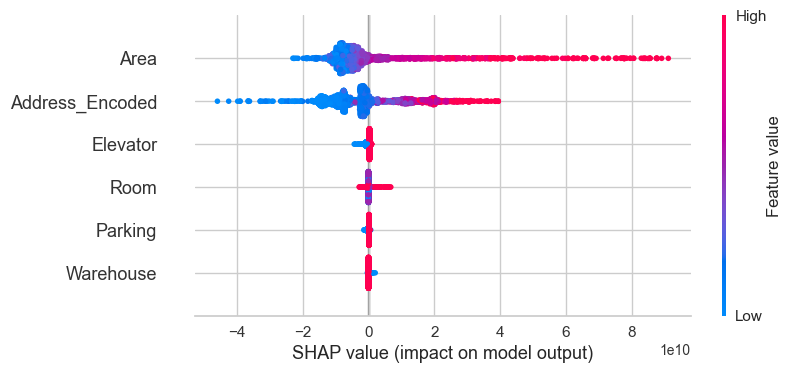

In [28]:
shap.plots.beeswarm(shap_values_lgbm)

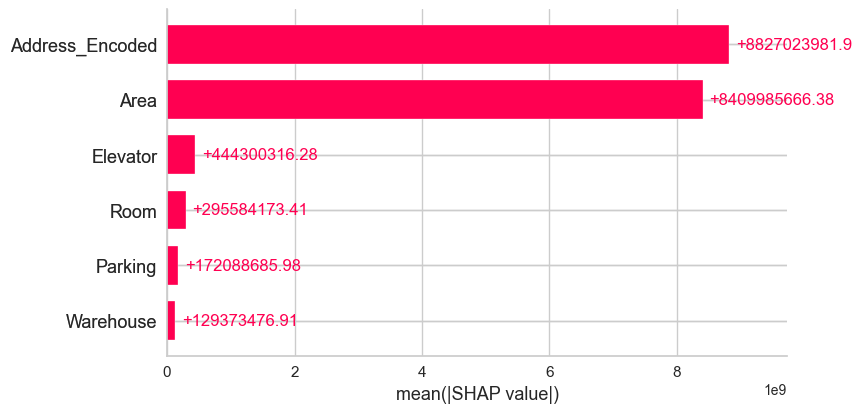

In [21]:
shap.plots.bar(shap_values_lgbm)

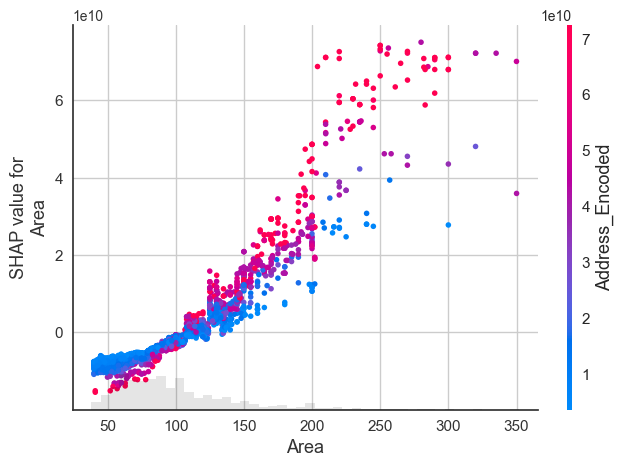

In [22]:
shap.plots.scatter(shap_values_lgbm[:, "Area"], color=shap_values_lgbm)

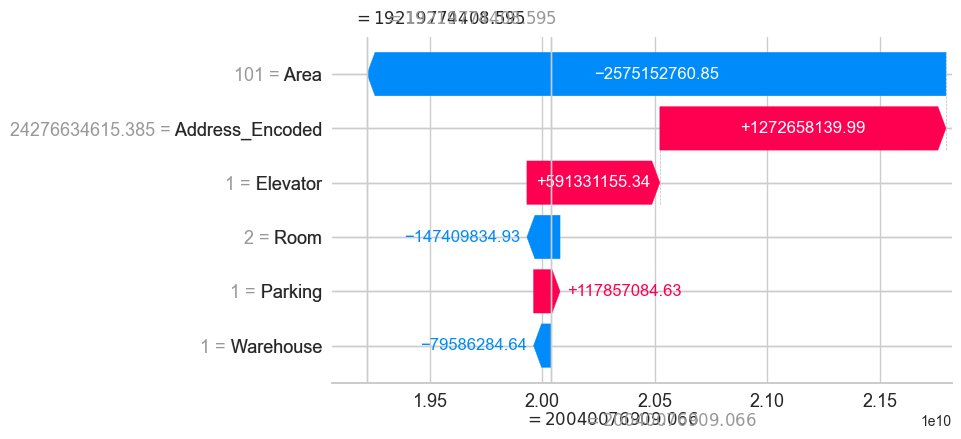

In [23]:
shap.plots.waterfall(shap_values_lgbm[65])

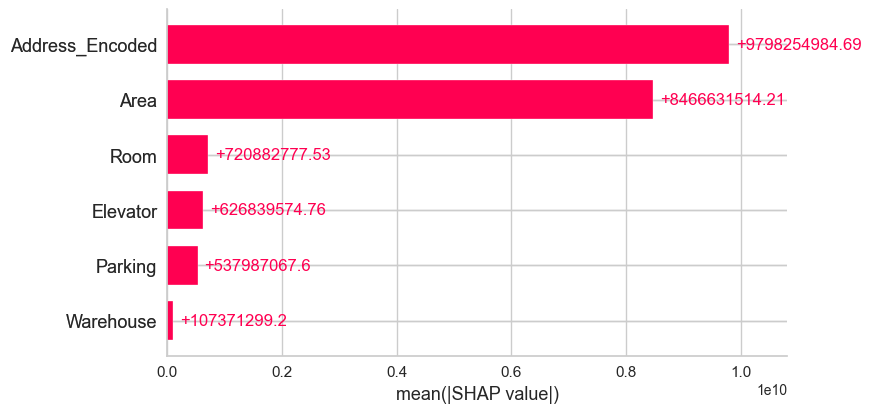

In [29]:
explainer_catboost = shap.TreeExplainer(catboost)
shap_values_catboost = explainer_catboost(X_train)
shap.plots.bar(shap_values_catboost)

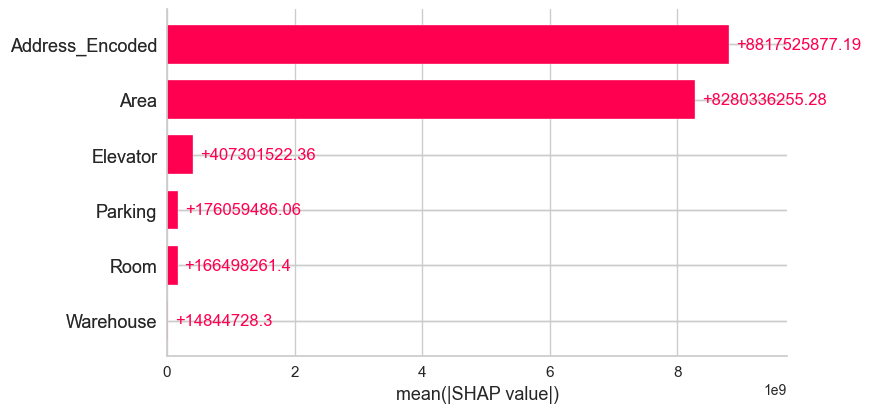

In [30]:
explainer_gbr = shap.Explainer(gbr, X_train)
shap_values_gbr = explainer_gbr(X_train)
shap.plots.bar(shap_values_gbr)

 99%|===================| 2645/2671 [00:37<00:00]        

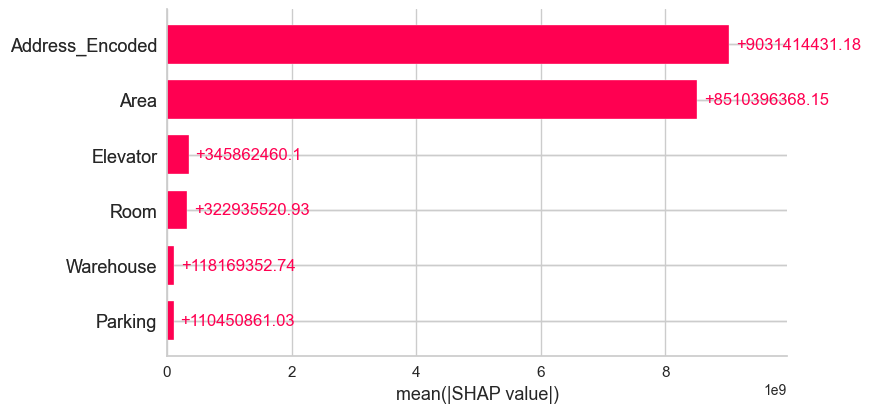

In [31]:
explainer_rf = shap.Explainer(rf, X_train)
shap_values_rf = explainer_rf(X_train)
shap.plots.bar(shap_values_rf)

## Saving Final Model

In [32]:
blender = VotingRegressor(estimators=[
    ('lgbm', lgb.LGBMRegressor(random_state=0)),
    ('catboost', cb.CatBoostRegressor(verbose=False, random_state=0)),
    ('rf', RandomForestRegressor(random_state=0))
])

blender.fit(X, y)

joblib.dump(blender, '../models/tehran_house_price_pipeline.pkl')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000173 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 309
[LightGBM] [Info] Number of data points in the train set: 3339, number of used features: 6
[LightGBM] [Info] Start training from score 21896239098.288109


['../models/tehran_house_price_pipeline.pkl']